# 04 Gaussian Copula Model

## Credit Risk Basket CDS Pricing

### Objective

The objective of this notebook is to simulate correlated default scenarios using the Gaussian Copula model.

The estimated correlation matrix from Notebook 03 and the default probabilities from Notebook 02 are combined to generate correlated uniform random variables, which will later be transformed into default times for Basket CDS pricing.

## Step 1 Import Required Libraries

This notebook uses:

- NumPy for simulation
- pandas for data handling
- scipy.stats for probability distributions
- matplotlib for visualization

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm

## Step 2 Load Estimated Correlation Matrix

The Pearson correlation matrix estimated in Notebook 03 is used as the dependence structure in the Gaussian Copula model.

In [5]:
prices = pd.read_csv("../Data/bank_prices.csv", index_col=0)

returns = prices.pct_change().dropna()

corr_matrix = returns.corr()

corr_matrix

,BAC,C,GS,JPM,MS
BAC,1.000000,0.785958,0.714061,0.723304,0.705794
C,0.785958,1.000000,0.684346,0.703900,0.663203
GS,0.714061,0.684346,1.000000,0.687839,0.732027
JPM,0.723304,0.703900,0.687839,1.000000,0.615057
MS,0.705794,0.663203,0.732027,0.615057,1.000000


## Step 3 Verify Correlation Matrix

Before simulation, the correlation matrix is checked to ensure it is suitable for multivariate normal sampling.

The matrix should be symmetric and positive semi-definite.

In [6]:
np.allclose(corr_matrix, corr_matrix.T)

True

## Step 4 Generate Correlated Normal Variables

Random samples are drawn from a multivariate normal distribution using the estimated correlation matrix.

Each simulation represents one possible joint market scenario for the reference entities.

In [7]:
n_simulations = 10000

Z = np.random.multivariate_normal(
    mean=np.zeros(5),
    cov=corr_matrix,
    size=n_simulations
)

Z.shape

(10000, 5)

## Step 5 Transform Normal Variables to Uniform Variables

The Gaussian Copula transforms correlated standard normal variables into correlated uniform variables using the standard normal cumulative distribution function (CDF).

These uniform variables preserve the dependence structure while allowing flexible marginal default distributions.

In [8]:
U = norm.cdf(Z)

U[:5]

array([[0.40727064, 0.13199348, 0.43003144, 0.16634087, 0.30950493],
       [0.29402271, 0.53405588, 0.24054931, 0.08391763, 0.58812937],
       [0.49662234, 0.58770747, 0.27128812, 0.67193894, 0.70178736],
       [0.82978233, 0.84600689, 0.73953475, 0.12969322, 0.43956031],
       [0.9090366 , 0.79740884, 0.3898103 , 0.37903349, 0.44035393]])

## Step 6 Inspect Simulated Uniform Variables

The simulated values should lie between 0 and 1 and approximately follow a uniform distribution.

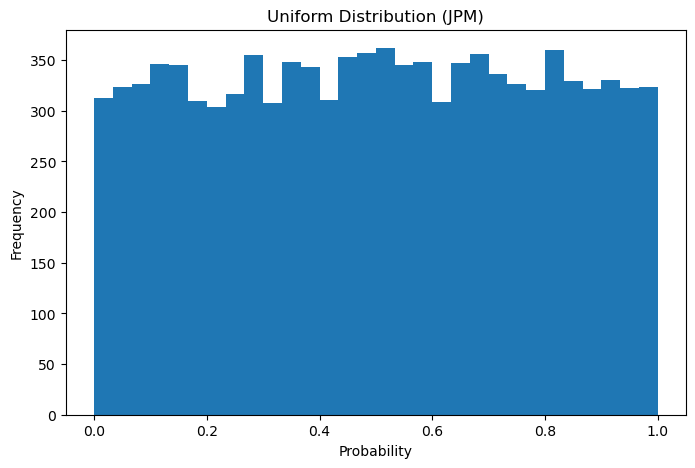

In [9]:
plt.figure(figsize=(8,5))

plt.hist(U[:,0], bins=30)

plt.title("Uniform Distribution (JPM)")

plt.xlabel("Probability")

plt.ylabel("Frequency")

plt.show()

# Business Interpretation

The Gaussian Copula model preserves the estimated dependence structure while transforming correlated normal variables into correlated uniform variables.

These uniform variables represent the joint behaviour of the reference entities and serve as the key inputs for simulating correlated default events.

This approach captures the possibility that multiple firms may experience financial distress simultaneously during adverse market conditions.

# Summary

In this notebook we:

- Loaded the estimated correlation matrix
- Verified its suitability for simulation
- Generated correlated normal variables
- Applied the Gaussian Copula transformation
- Produced correlated uniform random variables

These simulated uniform variables will be transformed into default times and used to price Basket CDS contracts in the next notebook.